In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [2]:
df=pd.read_csv('Alegerian_forest_fires_cleaned_datset.csv')

In [3]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [4]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [5]:
## drop month ,year, day
df.drop(['day','month','year'],axis=1, inplace=True)

In [6]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [7]:
df['Classes'].value_counts()

Classes
fire             131
not fire         100
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [8]:
## encoding
df['Classes']=np.where(df['Classes'].str.contains("not fire"),0,1)

In [9]:
df.tail()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
237,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,1,1
238,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,0,1
239,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,0,1
240,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,0,1
241,24,64,15,0.2,67.3,3.8,16.5,1.2,4.8,0.5,0,1


In [10]:
df['Classes'].value_counts()

Classes
1    137
0    105
Name: count, dtype: int64

In [11]:
## Independent and dependent
x=df.drop('FWI',axis=1)
y=df['FWI']

In [12]:
x.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0


In [13]:
y

0      0.5
1      0.4
2      0.1
3      0.0
4      0.5
      ... 
237    6.5
238    0.0
239    0.2
240    0.7
241    0.5
Name: FWI, Length: 242, dtype: float64

In [14]:
## train_test_split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [15]:
x_train.shape,x_test.shape

((181, 11), (61, 11))

In [16]:
## feature selection based on correlation
x_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.642116,-0.283958,-0.339198,0.690400,0.490509,0.372772,0.619623,0.462185,0.522713,0.257797
RH,-0.642116,1.000000,0.230015,0.232270,-0.623574,-0.412296,-0.243851,-0.688792,-0.361568,-0.429787,-0.373604
Ws,-0.283958,0.230015,1.000000,0.173672,-0.100993,-0.002064,0.104371,0.036868,0.038210,-0.020818,-0.264279
Rain,-0.339198,0.232270,0.173672,1.000000,-0.554577,-0.284464,-0.294927,-0.342447,-0.294981,-0.375967,-0.065393
FFMC,0.690400,-0.623574,-0.100993,-0.554577,1.000000,0.617972,0.535606,0.744434,0.607916,0.767552,0.201530
DMC,0.490509,-0.412296,-0.002064,-0.284464,0.617972,1.000000,0.875680,0.693483,0.983283,0.621483,0.186645
DC,0.372772,-0.243851,0.104371,-0.294927,0.535606,0.875680,1.000000,0.554695,0.947126,0.558952,-0.093214
ISI,0.619623,-0.688792,0.036868,-0.342447,0.744434,0.693483,0.554695,1.000000,0.661385,0.753798,0.249473
BUI,0.462185,-0.361568,0.038210,-0.294981,0.607916,0.983283,0.947126,0.661385,1.000000,0.619943,0.084489
Classes,0.522713,-0.429787,-0.020818,-0.375967,0.767552,0.621483,0.558952,0.753798,0.619943,1.000000,0.149958


<Axes: >

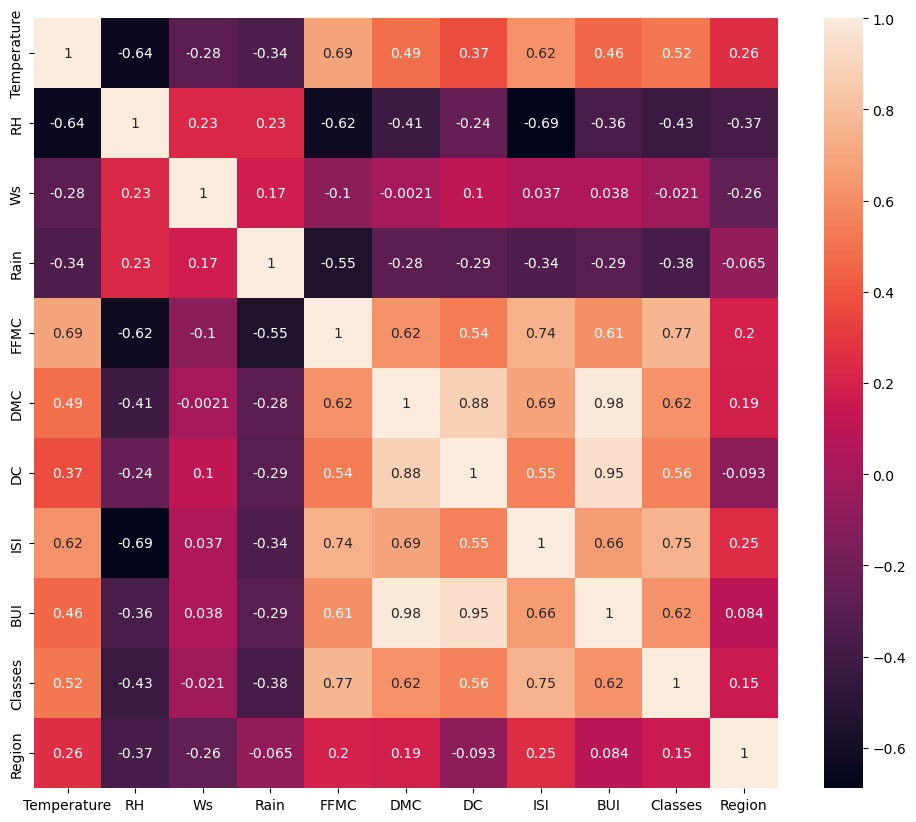

In [17]:
## checking for multicollinearity
plt.figure(figsize=(12,10))
corr=x_train.corr()
sns.heatmap(corr,annot=True)

In [22]:
def correlation(datset, threshold):
    col_corr = set()
    corr_matrix =datset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
             if abs(corr_matrix.iloc[i,j])>threshold:
                 colname = corr_matrix.columns[i]
                 col_corr.add(colname)
    return  col_corr

In [23]:
## threshold domain expertise
corr_features=correlation(x_train,0.85)

In [24]:
corr_features

{'BUI', 'DC'}

In [25]:
x_train.drop(corr_features, axis=1,inplace=True)
x_test.drop(corr_features, axis=1,inplace=True)
x_train.shape,x_test.shape

((181, 9), (61, 9))

feature scalling or standardization

In [28]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [29]:
x_train_scaled

array([[-0.28566503,  0.53627031,  0.56313398, ..., -0.75765861,
        -1.07459849, -0.99449032],
       [-0.0191425 , -0.53924134, -0.54477091, ...,  0.07462287,
         0.93058013,  1.00554021],
       [-0.81871009, -1.48031403, -2.7605807 , ..., -0.47230496,
         0.93058013,  1.00554021],
       ...,
       [-2.68436779,  1.54456248, -0.17546928, ..., -1.11435067,
        -1.07459849, -0.99449032],
       [ 1.04694761, -0.47202186,  0.19383235, ...,  0.83556593,
         0.93058013,  1.00554021],
       [-0.81871009,  1.67900144, -0.91407254, ..., -0.82899702,
        -1.07459849, -0.99449032]], shape=(181, 9))

## Box plot to understand effect of standard scaler 

Text(0.5, 1.0, 'x_train after scaling')

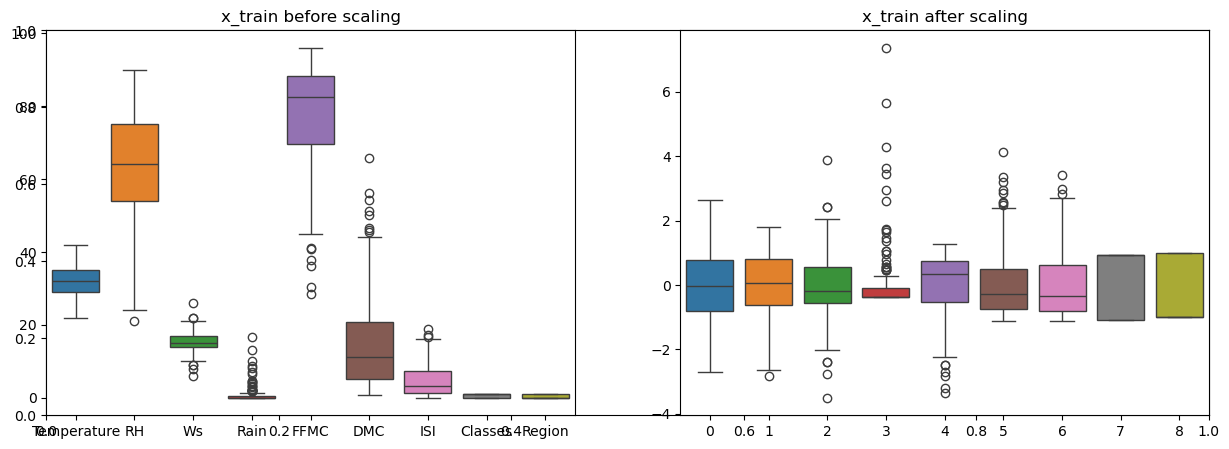

In [30]:
plt.subplots(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(data=x_train)
plt.title('x_train before scaling')
plt.subplot(1,2,2)
sns.boxplot(data=x_train_scaled)
plt.title('x_train after scaling')


## Linear Regression Model

Mean absolute error:  0.6105358982195593
R2 score:  0.9814531013040754


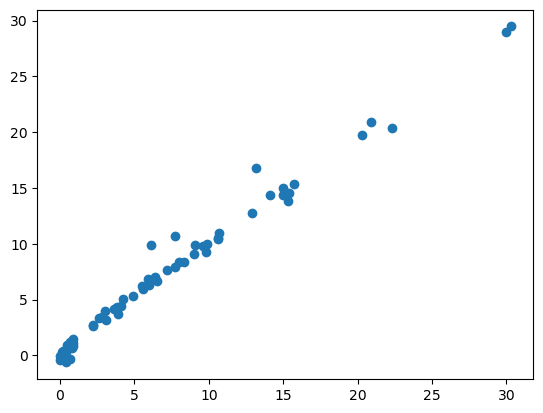

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
linreg=LinearRegression()
linreg.fit(x_train_scaled,y_train)
y_pred=linreg.predict(x_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("Mean absolute error: ",mae)
print("R2 score: ", score)
plt.scatter(y_test,y_pred)

## lasso regression

Mean absolute error:  1.143037374925893
R2 score:  0.9511916435874703


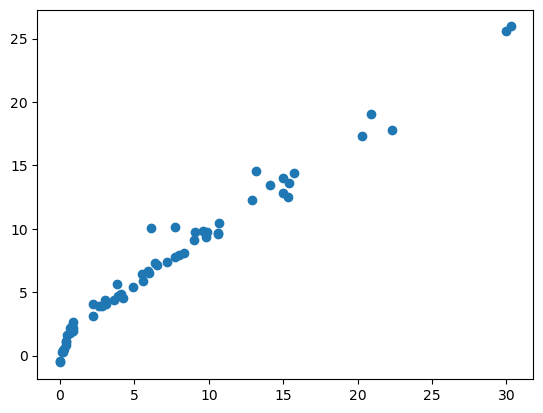

In [35]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
lasso = Lasso()
lasso.fit(x_train_scaled, y_train)
y_pred=lasso.predict(x_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("Mean absolute error: ",mae)
print("R2 score: ", score)
plt.scatter(y_test,y_pred)

## Cross validation lasso

In [37]:
from sklearn.linear_model import LassoCV
lassocv=LassoCV(cv=5)
lassocv.fit(x_train_scaled,y_train)

,eps,0.001
,n_alphas,'deprecated'
,alphas,'warn'
,fit_intercept,True
,precompute,'auto'
,max_iter,1000
,tol,0.0001
,copy_X,True
,cv,5
,verbose,False
,n_jobs,None


In [38]:
lassocv.alpha_

np.float64(0.05238030388262537)

In [39]:
lassocv.alphas_

array([6.92436791, 6.45768869, 6.02246208, 5.61656829, 5.23803039,
       4.88500467, 4.55577171, 4.24872794, 3.9623779 , 3.69532689,
       3.44627422, 3.21400688, 2.99739357, 2.79537927, 2.60698007,
       2.43127834, 2.26741831, 2.11460191, 1.97208482, 1.8391729 ,
       1.7152188 , 1.5996188 , 1.49180984, 1.39126685, 1.29750012,
       1.21005296, 1.12849944, 1.05244235, 0.98151126, 0.91536069,
       0.85366844, 0.79613404, 0.74247727, 0.69243679, 0.64576887,
       0.60224621, 0.56165683, 0.52380304, 0.48850047, 0.45557717,
       0.42487279, 0.39623779, 0.36953269, 0.34462742, 0.32140069,
       0.29973936, 0.27953793, 0.26069801, 0.24312783, 0.22674183,
       0.21146019, 0.19720848, 0.18391729, 0.17152188, 0.15996188,
       0.14918098, 0.13912669, 0.12975001, 0.1210053 , 0.11284994,
       0.10524424, 0.09815113, 0.09153607, 0.08536684, 0.0796134 ,
       0.07424773, 0.06924368, 0.06457689, 0.06022462, 0.05616568,
       0.0523803 , 0.04885005, 0.04555772, 0.04248728, 0.03962

In [40]:
lassocv.mse_path_

array([[55.6434189 , 56.61852604, 38.45103538, 64.29127323, 67.83115556],
       [49.48911593, 50.35911108, 33.25816521, 58.68523567, 63.41072289],
       [43.39081034, 44.56350434, 28.55372715, 52.98191744, 57.24286817],
       [38.03127477, 39.490667  , 24.54838485, 47.97885238, 51.8291927 ],
       [33.35771351, 35.0485177 , 21.14522345, 43.58770358, 47.07477913],
       [29.28146448, 31.15707817, 18.2604159 , 38.81715602, 42.04789932],
       [25.72575715, 27.74642667, 15.821361  , 33.91753678, 36.96252586],
       [22.62336562, 24.75560639, 13.7652979 , 29.66081218, 32.52397145],
       [19.91590675, 22.13175882, 12.03794036, 25.96273797, 28.64879861],
       [17.55238345, 19.82851885, 10.59232299, 22.74975489, 25.26405944],
       [15.48892062, 17.80555251,  9.38800002, 19.9594437 , 22.30791796],
       [13.68679856, 16.02768332,  8.38994123, 17.53598632, 19.72485774],
       [12.11247783, 14.46415734,  7.56795108, 15.43136913, 17.46709014],
       [10.73675394, 13.08835732,  6.8

Mean absolute error:  0.6543565971334555
R2 score:  0.9806674771734334


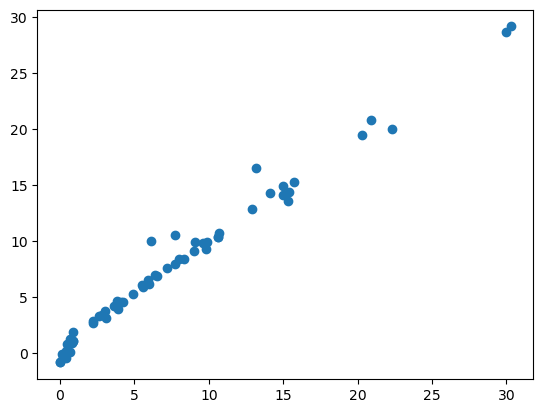

In [41]:
y_pred=lassocv.predict(x_test_scaled)
plt.scatter(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error: ",mae)
print("R2 score: ", score)

## Ridge regression model

Mean absolute error:  0.6413361371248575
R2 score:  0.9805386772103488


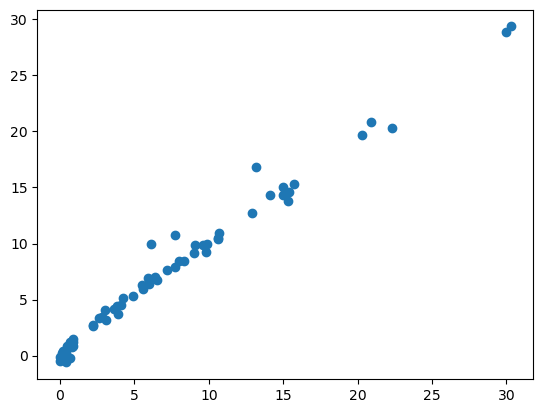

In [43]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
ridge = Ridge()
ridge.fit(x_train_scaled, y_train)
y_pred=ridge.predict(x_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("Mean absolute error: ",mae)
print("R2 score: ", score)
plt.scatter(y_test,y_pred)

Mean absolute error:  0.8929002602441306
R2 score:  0.9707384234241836


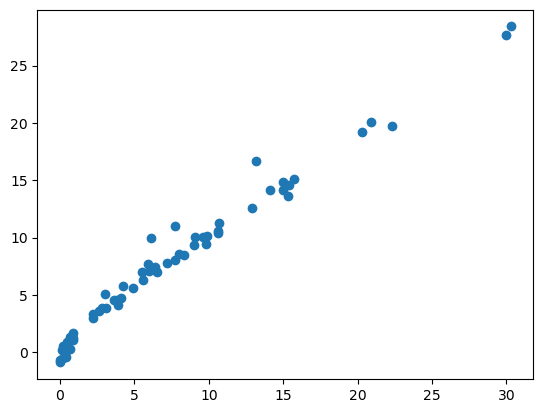

In [44]:
from sklearn.linear_model import RidgeCV
ridgecv=RidgeCV(cv=5)
ridgecv.fit(x_train_scaled,y_train)
y_pred=ridgecv.predict(x_test_scaled)
plt.scatter(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error: ",mae)
print("R2 score: ", score)

In [45]:
ridge.get_params()

{'alpha': 1.0,
 'copy_X': True,
 'fit_intercept': True,
 'max_iter': None,
 'positive': False,
 'random_state': None,
 'solver': 'auto',
 'tol': 0.0001}

## ElasticNet Regression

Mean absolute error:  1.936829802643094
R2 score:  0.8722521489238869


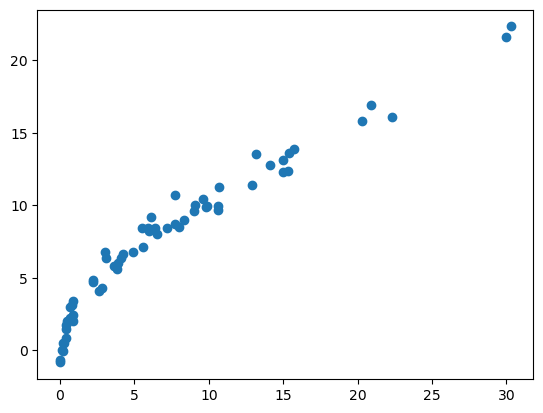

In [47]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
elastic = ElasticNet()
elastic.fit(x_train_scaled, y_train)
y_pred=elastic.predict(x_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("Mean absolute error: ",mae)
print("R2 score: ", score)
plt.scatter(y_test,y_pred)

Elasticnet cv

Mean absolute error:  0.7483782350253113
R2 score:  0.977300501235307


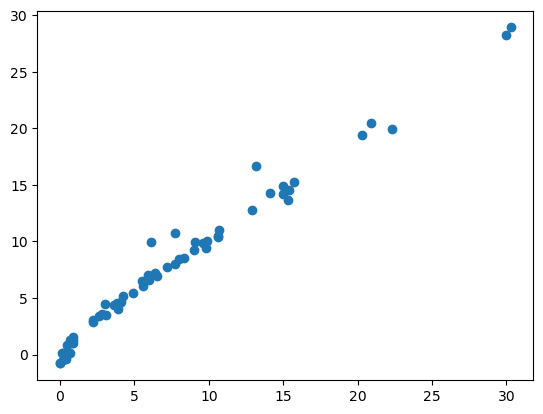

In [48]:
from sklearn.linear_model import ElasticNetCV
elasticcv=ElasticNetCV(cv=5)
elasticcv.fit(x_train_scaled,y_train)
y_pred=elasticcv.predict(x_test_scaled)
plt.scatter(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error: ",mae)
print("R2 score: ", score)

In [ ]:
## pickle the machine learning model , preprocessing model standardscaler


In [49]:
scaler

,copy,True
,with_mean,True
,with_std,True


In [51]:
ridge

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [53]:
import pickle
pickle.dump(scaler,open('scaler.pkl','wb'))
pickle.dump(ridge,open('ridge.pkl','wb'))